# 04. Full SR Inference and Downstream Segmentation with SynthSeg

In the previous notebooks, we trained lightweight super-resolution (SR) models for fast demonstration. Here, we use stronger SR checkpoints and evaluate whether SR helps a downstream segmentation task.

This notebook covers:

1. Running full SR checkpoints for UNet, DDPM, and Flow Matching.
2. Visualizing 3D SR results on example cases.
3. Applying SynthSeg as a fixed brain MRI segmentation model.
4. Comparing LR/SR segmentations with the Neurite-OASIS ground-truth labels.

The idea is simple: if SR restores anatomically meaningful structures, SynthSeg should produce segmentations closer to the HR ground truth.

> This notebook focuses on visualization and analysis. Full SR inference and SynthSeg prediction should be run from the project root in a terminal, not inside notebook cells.


## 1. Full SR checkpoints

For a more complete evaluation, we trained larger 2.5D SR models using `config/*_full.yaml`. Compared with the quick tutorial setting, the full setting uses larger models, `128` slices per sample, and longer training.

This setting requires about **70 GB GPU memory** and **10 hours** of training. To avoid retraining, we provide checkpoints for all three models: [Download link]()

After downloading the checkpoints, run the following commands from the project root:

```bash
python test.py --config config/unet_2p5d_full.yaml --ckpt your_full_unet_ckpt_path.ckpt

python test.py --config config/ddpm_2p5d_full.yaml --ckpt your_full_ddpm_ckpt_path.ckpt

python test.py --config config/fm_2p5d_full.yaml --ckpt your_full_fm_ckpt_path.ckpt
```


## 2. Visualize full SR examples

The test script saves 3D inference results under `results/`. You can visualize your own outputs using the same approach as in Section 6 of `03_evaluation.ipynb`.

For convenience, this notebook also includes several precomputed examples under `examples/`.


In [1]:
from pathlib import Path
from utils import visualize_examples_sr, visualize_examples_sr_with_seg, compute_examples_seg_dice_table

project_root = Path.cwd().resolve()
if project_root.name == "tutorial":
    project_root = project_root.parent

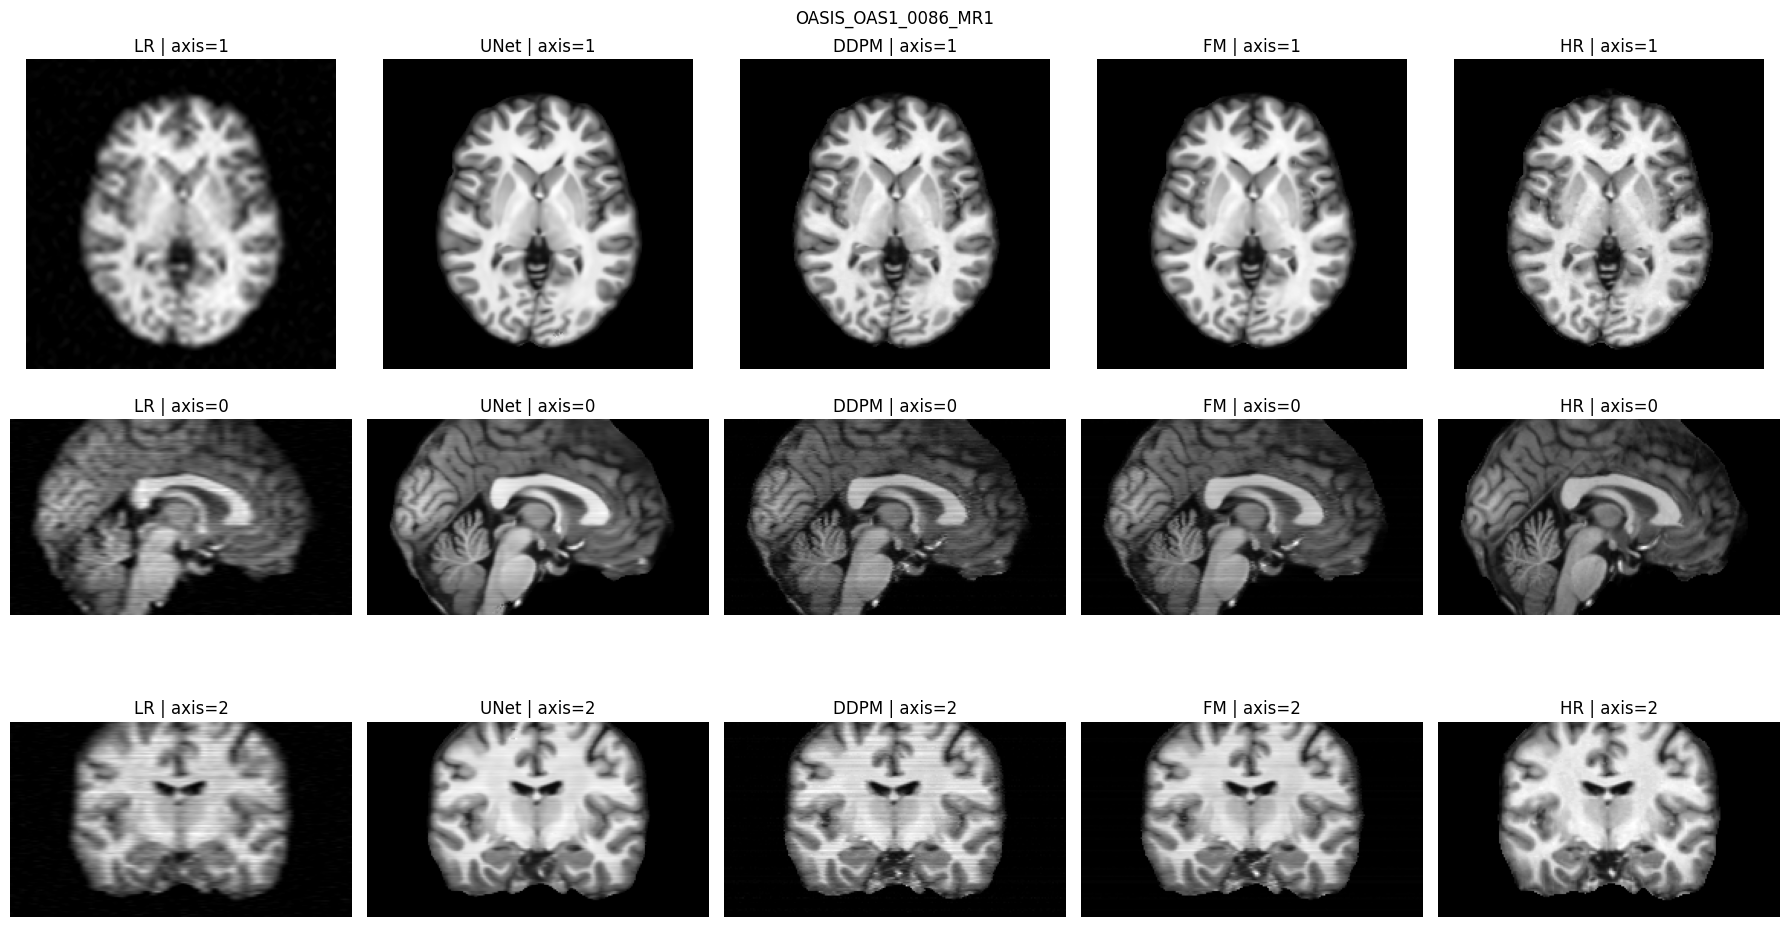

In [2]:
examples_root = project_root / "examples"
lr_dir = examples_root / "LR"
hr_dir = examples_root / "HR"
unet_sr_dir = examples_root / "unet_2p5d_full"
ddpm_sr_dir = examples_root / "ddpm_2p5d_full"
fm_sr_dir = examples_root / "fm_2p5d_full"

visualize_examples_sr(
    lr_dir=lr_dir,
    hr_dir=hr_dir,
    unet_sr_dir=unet_sr_dir,
    ddpm_sr_dir=ddpm_sr_dir,
    fm_sr_dir=fm_sr_dir,
    max_cases=1,
)

## 3. Downstream validation with SynthSeg

PSNR and SSIM measure image-level similarity, but they do not directly show whether SR improves downstream medical image analysis. Here, we use [SynthSeg](https://github.com/BBillot/SynthSeg) as a fixed downstream segmentation model.

SynthSeg is a contrast-agnostic brain MRI segmentation method. Since it can handle different MRI contrasts and resolutions without retraining, it is suitable for comparing LR and SR images under the same segmentation pipeline.

In this notebook, we evaluate downstream segmentation as follows:

- Run SynthSeg on LR and SR images.
- Use the Neurite-OASIS segmentation labels as ground truth.
- Compute Dice scores between SynthSeg outputs and the ground truth labels.

This tests whether SR makes the image more useful for anatomical segmentation.


## 4. Install SynthSeg and run segmentation

Install SynthSeg in a **separate environment**, because it depends on TensorFlow/Keras and may conflict with the PyTorch SR environment.

Official installation guide: https://github.com/BBillot/SynthSeg#installation

Run SynthSeg from the SynthSeg repository:

```bash
python ./scripts/commands/SynthSeg_predict.py --i <your_LR_or_SR_folder> --o <your_output_seg_folder> --v1 --fast
```

Add `--cpu` if GPU setup causes compatibility issues:

In this notebook, we provide precomputed SynthSeg outputs for the example cases. We also map SynthSeg labels to the Neurite-OASIS label space before computing Dice.


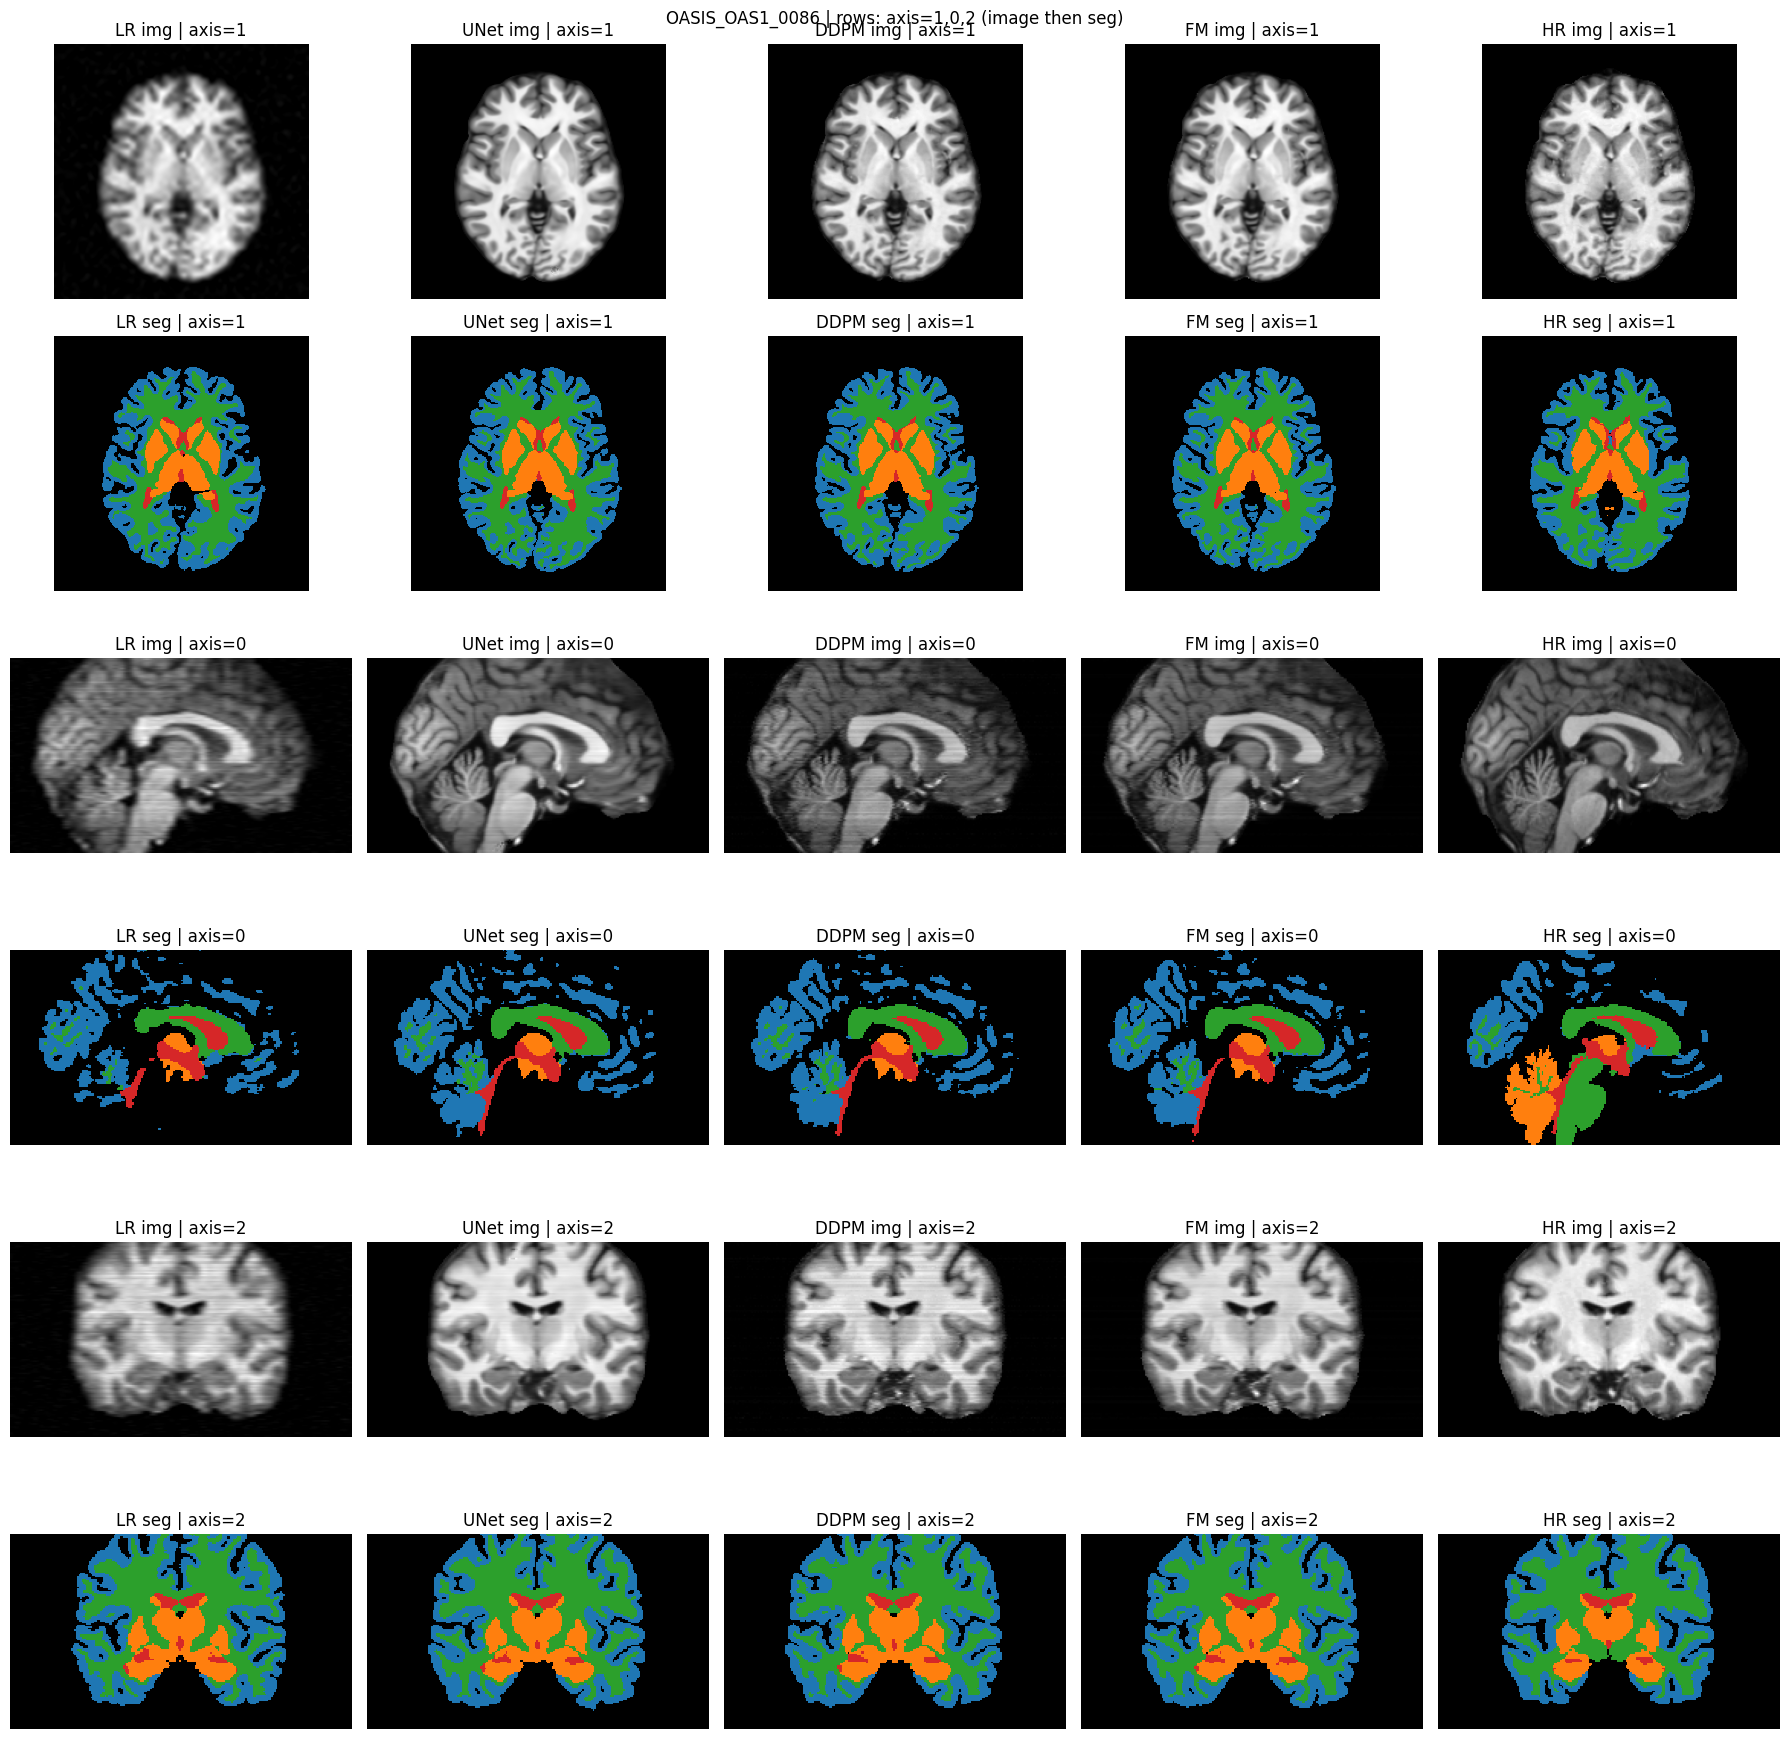

In [3]:
# Segmentation folders are stored as "seg/" under each image directory.
# SynthSeg outputs are mapped to the Neurite-OASIS label space in utils.py.
visualize_examples_sr_with_seg(
    lr_dir=lr_dir,
    hr_dir=hr_dir,
    unet_sr_dir=unet_sr_dir,
    ddpm_sr_dir=ddpm_sr_dir,
    fm_sr_dir=fm_sr_dir,
    max_cases=1,
)

## 5. Compute Dice scores

We compare the segmentation results against the Neurite-OASIS ground-truth labels:

- `SynthSeg(LR)` vs. ground truth.
- `SynthSeg(SR)` vs. ground truth.

Background label `0` is ignored. The code reports per-case Dice scores and a summary table for LR, UNet, DDPM, and Flow Matching.


In [5]:
case_df, summary_df = compute_examples_seg_dice_table(
    lr_dir=lr_dir,
    hr_dir=hr_dir,
    unet_sr_dir=unet_sr_dir,
    ddpm_sr_dir=ddpm_sr_dir,
    fm_sr_dir=fm_sr_dir,
)

# print("Per-case Dice (each sample):")
# display(case_df.round(4))

print("\nSummary Dice table (rows=LR/UNet/DDPM/FM):")
display(summary_df.round(4))


Summary Dice table (rows=LR/UNet/DDPM/FM):


,Cortex,SubcorticalGM,WhiteMatter,CSF_Ventricles,MeanDice
model,,,,,
LR,0.7182,0.4042,0.8521,0.8888,0.7158
UNet,0.7368,0.4169,0.8820,0.9045,0.7350
DDPM,0.7341,0.4183,0.8805,0.9034,0.7341
FM,0.7370,0.4181,0.8813,0.9033,0.7349
